In [100]:
import pandas as pd

In [101]:
import pandas as pd

df = pd.read_csv("../data/50000 Sales Records.csv",parse_dates=["Order Date","Ship Date"])

In [102]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,Namibia,Household,Offline,M,2015-08-31,897751939,2015-10-12,3604,668.27,502.54,2408445.08,1811154.16,597290.92
1,Europe,Iceland,Baby Food,Online,H,2010-11-20,599480426,2011-01-09,8435,255.28,159.42,2153286.80,1344707.70,808579.10
2,Europe,Russia,Meat,Online,L,2017-06-22,538911855,2017-06-25,4848,421.89,364.69,2045322.72,1768017.12,277305.60
3,Europe,Moldova,Meat,Online,L,2012-02-28,459845054,2012-03-20,7225,421.89,364.69,3048155.25,2634885.25,413270.00
4,Europe,Malta,Cereal,Online,M,2010-08-12,626391351,2010-09-13,1975,205.70,117.11,406257.50,231292.25,174965.25


In [103]:
df.shape

(50000, 14)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Region          50000 non-null  object        
 1   Country         50000 non-null  object        
 2   Item Type       50000 non-null  object        
 3   Sales Channel   50000 non-null  object        
 4   Order Priority  50000 non-null  object        
 5   Order Date      50000 non-null  datetime64[ns]
 6   Order ID        50000 non-null  int64         
 7   Ship Date       50000 non-null  datetime64[ns]
 8   Units Sold      50000 non-null  int64         
 9   Unit Price      50000 non-null  float64       
 10  Unit Cost       50000 non-null  float64       
 11  Total Revenue   50000 non-null  float64       
 12  Total Cost      50000 non-null  float64       
 13  Total Profit    50000 non-null  float64       
dtypes: datetime64[ns](2), float64(5), int64(2), object(5)


In [105]:
df.isna().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df.describe()

,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,50000,5.000000e+04,50000,50000.00000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04
mean,2013-10-11 06:32:29.184000,5.497330e+08,2013-11-05 06:39:15.264000,4999.61898,265.651350,187.322482,1.323716e+06,9.331574e+05,3.905587e+05
min,2010-01-01 00:00:00,1.000132e+08,2010-01-02 00:00:00,1.00000,9.330000,6.920000,2.799000e+01,2.076000e+01,7.230000e+00
25%,2011-11-15 00:00:00,3.240070e+08,2011-12-11 00:00:00,2498.00000,81.730000,35.840000,2.764871e+05,1.606370e+05,9.415092e+04
50%,2013-10-09 00:00:00,5.504224e+08,2013-11-02 00:00:00,5017.50000,154.060000,97.440000,7.813247e+05,4.671040e+05,2.795364e+05
75%,2015-09-04 00:00:00,7.767824e+08,2015-09-30 00:00:00,7493.25000,421.890000,263.330000,1.808642e+06,1.190390e+06,5.642867e+05
max,2017-07-28 00:00:00,9.999995e+08,2017-09-16 00:00:00,10000.00000,668.270000,524.960000,6.682032e+06,5.249075e+06,1.738178e+06
std,NaN,2.609179e+08,NaN,2884.33508,216.916752,175.580570,1.463891e+06,1.145548e+06,3.777588e+05


In [108]:
df["Order ID"].nunique()

50000

In [109]:
len(df)

50000

In [110]:
df['Order ID'].duplicated().sum()

np.int64(0)

In [111]:
(df["Units Sold"] * df["Unit Price"] - df["Total Revenue"]).abs().max()

9.313225746154785e-10

In [112]:
(df["Units Sold"] * df["Unit Cost"] - df["Total Cost"]).abs().max()

9.313225746154785e-10

In [113]:
(df["Total Revenue"] - df["Total Cost"] - df["Total Profit"]).abs().max()

6.984919309616089e-10

In [114]:
df["Order Date"].min()


Timestamp('2010-01-01 00:00:00')

In [115]:
df["Order Date"].max()

Timestamp('2017-07-28 00:00:00')

In [116]:
df["Order Date"].nunique()

2766

In [117]:
df["Order Date"].dt.year.value_counts().sort_index()

Order Date
2010    6594
2011    6757
2012    6634
2013    6523
2014    6596
2015    6570
2016    6551
2017    3775
Name: count, dtype: int64

In [118]:
df["Order Date"].dt.to_period("M").value_counts().sort_index()

Order Date
2010-01    502
2010-02    538
2010-03    531
2010-04    537
2010-05    548
          ... 
2017-03    563
2017-04    545
2017-05    610
2017-06    536
2017-07    480
Freq: M, Name: count, Length: 91, dtype: int64

In [119]:
d = df["Order Date"].dt.to_period("Y").value_counts().sort_index().reset_index()

In [120]:
d

,Order Date,count
0,2010,6594
1,2011,6757
2,2012,6634
3,2013,6523
4,2014,6596
5,2015,6570
6,2016,6551
7,2017,3775


In [121]:
monthly_demand = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Units Sold"]
      .sum()
      .reset_index()
)

monthly_demand.head(12)

,Order Date,Units Sold
0,2010-01,2416955
1,2010-02,2724860
2,2010-03,2557032
3,2010-04,2780481
4,2010-05,2757045
5,2010-06,2844228
6,2010-07,2676194
7,2010-08,3000733
8,2010-09,2692859
9,2010-10,2835289


In [122]:
monthly_demand["Units Sold"].describe()

count    9.100000e+01
mean     2.747043e+06
std      1.700930e+05
min      2.404223e+06
25%      2.646410e+06
50%      2.739138e+06
75%      2.869465e+06
max      3.092803e+06
Name: Units Sold, dtype: float64

In [123]:
monthly_demand.shape

(91, 2)

In [124]:
monthly_demand.sort_values("Units Sold", ascending=False).head(10)

,Order Date,Units Sold
52,2014-05,3092803
82,2016-11,3051106
71,2015-12,3039021
21,2011-10,3037996
28,2012-05,3031626
59,2014-12,3021706
7,2010-08,3000733
30,2012-07,2996787
36,2013-01,2974583
20,2011-09,2974414


In [125]:
monthly_demand.sort_values("Units Sold").head(10)

,Order Date,Units Sold
90,2017-07,2404223
0,2010-01,2416955
57,2014-10,2421817
37,2013-02,2421905
61,2015-02,2437945
49,2014-02,2456341
27,2012-04,2459399
83,2016-12,2477995
85,2017-02,2488645
63,2015-04,2496706


In [126]:
d

,Order Date,count
0,2010,6594
1,2011,6757
2,2012,6634
3,2013,6523
4,2014,6596
5,2015,6570
6,2016,6551
7,2017,3775


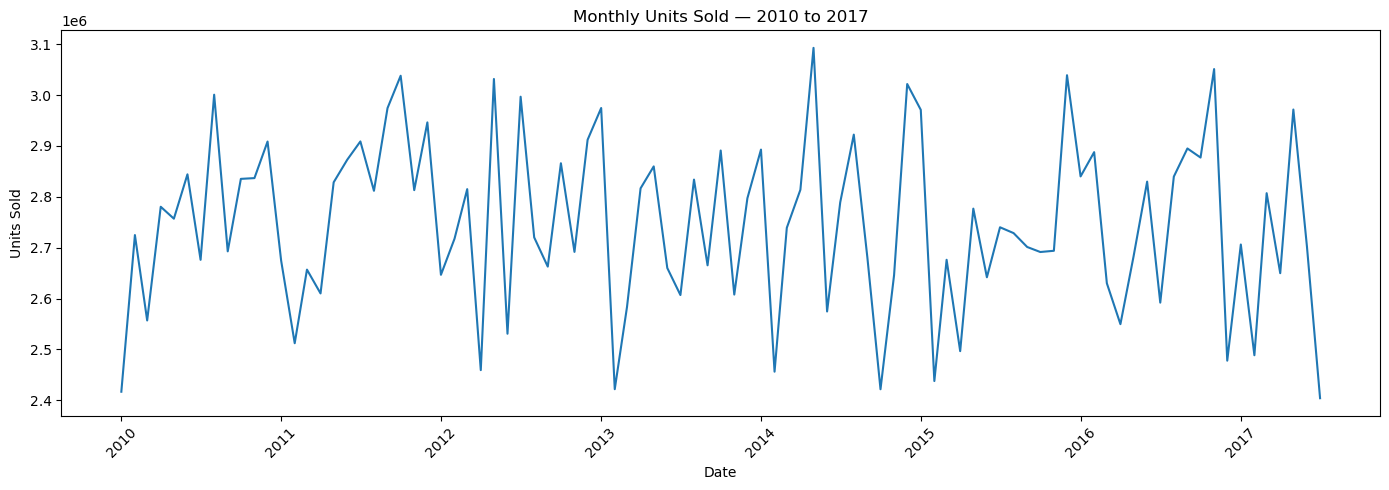

In [127]:
import matplotlib.pyplot as plt

monthly_demand["Order Date"] = monthly_demand["Order Date"].dt.to_timestamp()

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand["Order Date"],
    monthly_demand["Units Sold"]
)

plt.title("Monthly Units Sold — 2010 to 2017")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [128]:
monthly_demand["Month"] = monthly_demand["Order Date"].dt.month

In [129]:
monthly_demand.groupby("Month")["Units Sold"].agg(
    ["mean", "min", "max"]
)

,mean,min,max
Month,,,
1,2.765390e+06,2416955,2974583
2,2.580929e+06,2421905,2887814
3,2.683177e+06,2557032,2815082
4,2.647121e+06,2459399,2816701
5,2.875133e+06,2682846,3092803
6,2.707170e+06,2530941,2872964
7,2.714307e+06,2404223,2996787
8,2.836773e+06,2720263,3000733
9,2.753273e+06,2662857,2974414


In [130]:
expected_months = pd.date_range(
    start=monthly_demand["Order Date"].min(),
    end=monthly_demand["Order Date"].max(),
    freq="MS"
)

actual_months = monthly_demand["Order Date"]

missing_months = expected_months.difference(actual_months)

missing_months

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

In [131]:
print(df["Total Revenue"].sum())

print(df["Total Cost"].sum())


print(df["Total Profit"].sum())     


print(df["Units Sold"].sum())

print(df["Order ID"].nunique())

df["Total Profit"].sum() / df["Total Revenue"].sum() * 100

66185806881.22
46657869932.97
19527936948.25
249980949
50000


np.float64(29.504719921743504)

In [132]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          orders=("Order ID", "count"),
          units_sold=("Units Sold", "sum"),
          revenue=("Total Revenue", "sum"),
          cost=("Total Cost", "sum"),
          profit=("Total Profit", "sum")
      )
      .reset_index()
)

In [133]:
monthly_sales.head()

,Order Date,orders,units_sold,revenue,cost,profit
0,2010-01,502,2416955,6.297848e+08,4.554190e+08,1.743658e+08
1,2010-02,538,2724860,7.697528e+08,5.491157e+08,2.206372e+08
2,2010-03,531,2557032,7.118628e+08,5.042874e+08,2.075755e+08
3,2010-04,537,2780481,7.383854e+08,5.191112e+08,2.192742e+08
4,2010-05,548,2757045,7.439784e+08,5.277816e+08,2.161968e+08


In [134]:
monthly_sales.shape

(91, 6)

In [135]:
monthly_sales["profit_margin"] = (
    monthly_sales["profit"] /
    monthly_sales["revenue"] * 100
)

In [136]:
monthly_sales.head()

,Order Date,orders,units_sold,revenue,cost,profit,profit_margin
0,2010-01,502,2416955,6.297848e+08,4.554190e+08,1.743658e+08,27.686564
1,2010-02,538,2724860,7.697528e+08,5.491157e+08,2.206372e+08,28.663377
2,2010-03,531,2557032,7.118628e+08,5.042874e+08,2.075755e+08,29.159478
3,2010-04,537,2780481,7.383854e+08,5.191112e+08,2.192742e+08,29.696442
4,2010-05,548,2757045,7.439784e+08,5.277816e+08,2.161968e+08,29.059551


In [137]:
categorical_cols = [
    "Region",
    "Country",
    "Item Type",
    "Sales Channel",
    "Order Priority"
]

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].unique())


Region
Unique values: 7
['Sub-Saharan Africa' 'Europe' 'Asia' 'Middle East and North Africa'
 'Central America and the Caribbean' 'Australia and Oceania'
 'North America']

Country
Unique values: 185
['Namibia' 'Iceland' 'Russia' 'Moldova ' 'Malta' 'Indonesia' 'Djibouti'
 'Greece' 'Cameroon' 'Nigeria' 'Senegal' 'Afghanistan' 'India' 'Lebanon'
 'Turkey' 'Iraq' 'Rwanda' 'Ukraine' 'Finland' 'South Sudan'
 'Antigua and Barbuda ' 'Kuwait' 'United Kingdom' 'Saint Kitts and Nevis '
 'Saint Lucia' 'Tunisia ' 'Yemen' 'Guinea' 'Tuvalu' 'South Korea'
 'San Marino' 'Trinidad and Tobago' 'Kosovo' 'Hungary' 'Botswana' 'Serbia'
 'Guatemala' 'United Arab Emirates' 'Samoa ' 'Bahrain'
 'Saint Vincent and the Grenadines' 'Pakistan' 'Poland' 'Lithuania'
 'Sudan' 'Portugal' 'Fiji' 'Tanzania' 'Sao Tome and Principe' 'Cape Verde'
 'Greenland' 'Guinea-Bissau' 'Georgia' 'Jamaica' 'Bulgaria' 'Kazakhstan'
 'Grenada' 'Honduras' 'Mongolia' 'Belize' 'United States of America'
 'South Africa' 'Austria' 'Marshall Is

In [138]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [139]:
df["Ship Date"].min(), df["Ship Date"].max()

(Timestamp('2010-01-02 00:00:00'), Timestamp('2017-09-16 00:00:00'))

In [141]:
df["Country"] = df["Country"].str.strip()

In [142]:
country_region_check = (
    df.groupby("Country")["Region"]
      .nunique()
      .sort_values(ascending=False)
)

country_region_check.head(10)

Country
Afghanistan            1
Albania                1
Algeria                1
Andorra                1
Angola                 1
Antigua and Barbuda    1
Armenia                1
Australia              1
Austria                1
Azerbaijan             1
Name: Region, dtype: int64

In [143]:
country_region_check.max()

1

In [144]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          units_sold=("Units Sold", "sum"),
          revenue=("Total Revenue", "sum"),
          profit=("Total Profit", "sum"),
          orders=("Order ID", "count")
      )
      .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

monthly_sales = monthly_sales.sort_values("Order Date")

monthly_sales.head()

,Order Date,units_sold,revenue,profit,orders
0,2010-01-01,2416955,6.297848e+08,1.743658e+08,502
1,2010-02-01,2724860,7.697528e+08,2.206372e+08,538
2,2010-03-01,2557032,7.118628e+08,2.075755e+08,531
3,2010-04-01,2780481,7.383854e+08,2.192742e+08,537
4,2010-05-01,2757045,7.439784e+08,2.161968e+08,548


In [145]:
monthly_sales["Order Date"].min(), monthly_sales["Order Date"].max()

(Timestamp('2010-01-01 00:00:00'), Timestamp('2017-07-01 00:00:00'))

In [146]:
monthly_sales = monthly_sales.set_index("Order Date")

In [147]:
monthly_sales.asfreq("MS").isna().sum()

units_sold    0
revenue       0
profit        0
orders        0
dtype: int64

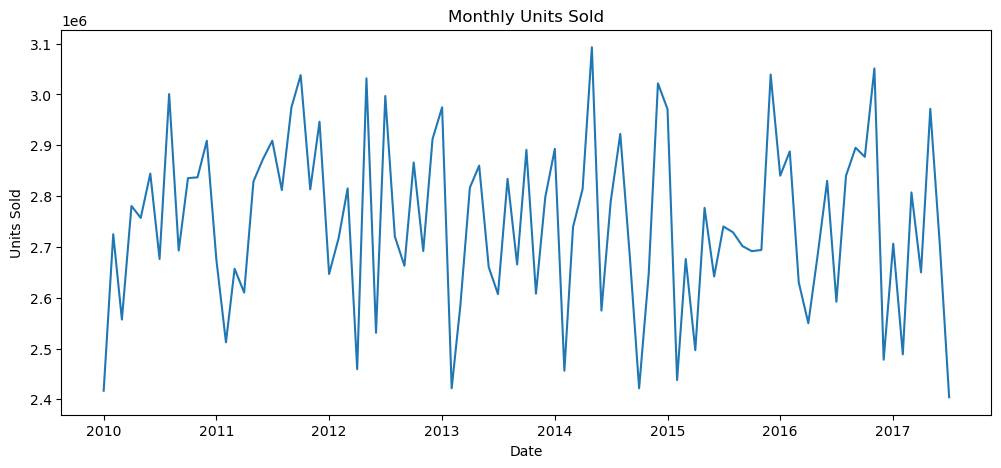

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales["units_sold"]
)

plt.title("Monthly Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

In [149]:
train = monthly_sales.loc[: "2016-12-01", "units_sold"]

test = monthly_sales.loc["2017-01-01":, "units_sold"]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (84,)
Test: (7,)


In [150]:
print(monthly_sales.index.min())
print(monthly_sales.index.max())
print(monthly_sales.shape)
print(test.index)

2010-01-01 00:00:00
2017-07-01 00:00:00
(91, 4)
DatetimeIndex(['2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01',
               '2017-05-01', '2017-06-01', '2017-07-01'],
              dtype='datetime64[ns]', name='Order Date', freq=None)


In [151]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

naive_forecast

Order Date
2017-01-01    2477995
2017-02-01    2477995
2017-03-01    2477995
2017-04-01    2477995
2017-05-01    2477995
2017-06-01    2477995
2017-07-01    2477995
dtype: int64

In [152]:
print("Last training value:", train.iloc[-1])
print("Forecast:")
print(naive_forecast)

Last training value: 2477995
Forecast:
Order Date
2017-01-01    2477995
2017-02-01    2477995
2017-03-01    2477995
2017-04-01    2477995
2017-05-01    2477995
2017-06-01    2477995
2017-07-01    2477995
dtype: int64


In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, naive_forecast)

rmse = np.sqrt(
    mean_squared_error(test, naive_forecast)
)

mape = np.mean(
    np.abs((test - naive_forecast) / test)
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 218868.7142857143
RMSE: 264490.93774996744
MAPE: 7.867104480508083


In [156]:
seasonal_naive_forecast = pd.Series(
    train.iloc[-12:].values[:len(test)],
    index=test.index
)

In [157]:
print(seasonal_naive_forecast)

Order Date
2017-01-01    2840118
2017-02-01    2887814
2017-03-01    2630147
2017-04-01    2549757
2017-05-01    2682846
2017-06-01    2829870
2017-07-01    2592064
dtype: int64


In [158]:
mae = mean_absolute_error(test, seasonal_naive_forecast)

rmse = np.sqrt(
    mean_squared_error(test, seasonal_naive_forecast)
)

mape = np.mean(
    np.abs((test - seasonal_naive_forecast) / test)
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 201985.7142857143
RMSE: 224699.24026573834
MAPE: 7.614925908738653


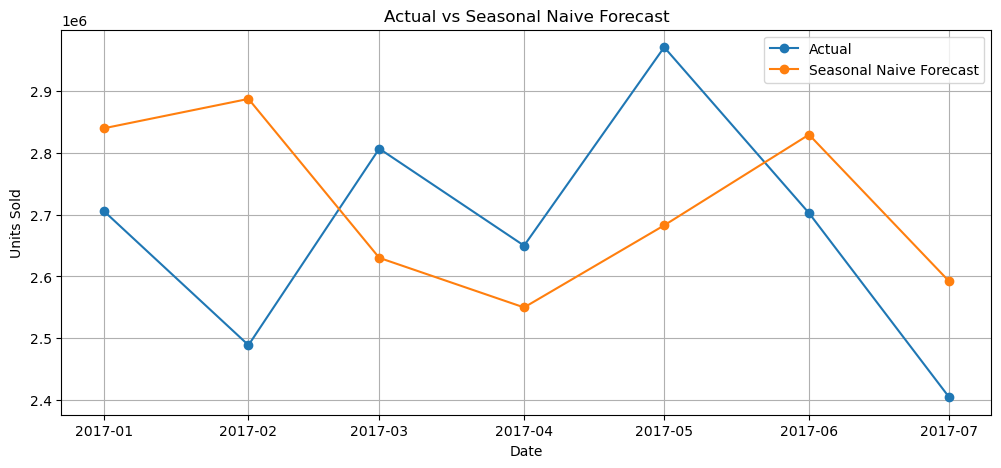

In [159]:
plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test,
    marker="o",
    label="Actual"
)

plt.plot(
    seasonal_naive_forecast.index,
    seasonal_naive_forecast,
    marker="o",
    label="Seasonal Naive Forecast"
)

plt.title("Actual vs Seasonal Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)

plt.show()

In [160]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.793266532016853
p-value: 6.27096305977436e-17


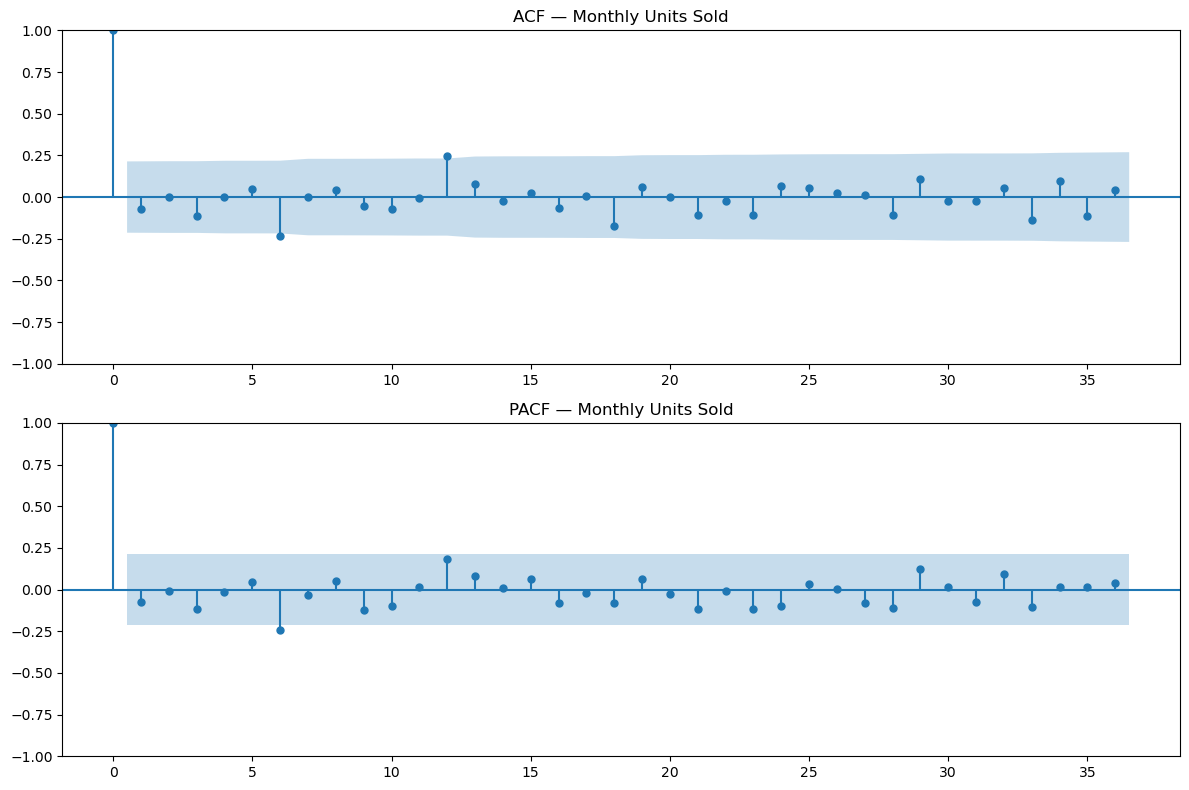

In [161]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(train, lags=36, ax=ax[0])
plot_pacf(train, lags=36, ax=ax[1])

ax[0].set_title("ACF — Monthly Units Sold")
ax[1].set_title("PACF — Monthly Units Sold")

plt.tight_layout()
plt.show()

In [162]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_1 = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_1_fit = sarima_1.fit(disp=False)

print(sarima_1_fit.summary())

c:\Users\Sanket Jadhav\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Sanket Jadhav\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         units_sold   No. Observations:                   84
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -952.448
Date:                            Thu, 08 Oct 2026   AIC                           1914.897
Time:                                    17:29:43   BIC                           1926.139
Sample:                                01-01-2010   HQIC                          1919.362
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0075      0.627      0.012      0.990      -1.222       1.237
ma.L1         -0.2268      0.577   

In [163]:
sarima_1_forecast = sarima_1_fit.forecast(steps=len(test))

print(sarima_1_forecast)

2017-01-01    2.929152e+06
2017-02-01    2.887622e+06
2017-03-01    2.621221e+06
2017-04-01    2.542913e+06
2017-05-01    2.672984e+06
2017-06-01    2.824432e+06
2017-07-01    2.581437e+06
Freq: MS, Name: predicted_mean, dtype: float64


In [164]:
sarima_1_mae = mean_absolute_error(test, sarima_1_forecast)

sarima_1_rmse = np.sqrt(
    mean_squared_error(test, sarima_1_forecast)
)

sarima_1_mape = np.mean(
    np.abs((test - sarima_1_forecast) / test)
) * 100

print("MAE :", sarima_1_mae)
print("RMSE:", sarima_1_rmse)
print("MAPE:", sarima_1_mape)

MAE : 216044.05226709894
RMSE: 236114.08683086868
MAPE: 8.121648027049643


In [165]:
sarima_2 = SARIMAX(
    train,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_2_fit = sarima_2.fit(disp=False)

sarima_2_forecast = sarima_2_fit.forecast(
    steps=len(test)
)

sarima_2_mae = mean_absolute_error(
    test,
    sarima_2_forecast
)

sarima_2_rmse = np.sqrt(
    mean_squared_error(test, sarima_2_forecast)
)

sarima_2_mape = np.mean(
    np.abs((test - sarima_2_forecast) / test)
) * 100

print("MAE :", sarima_2_mae)
print("RMSE:", sarima_2_rmse)
print("MAPE:", sarima_2_mape)

c:\Users\Sanket Jadhav\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Sanket Jadhav\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE : 328047.34203710814
RMSE: 375184.778260999
MAPE: 11.885243596572028


In [166]:
sarima_3 = SARIMAX(
    train,
    order=(0, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_3_fit = sarima_3.fit(disp=False)

sarima_3_forecast = sarima_3_fit.forecast(
    steps=len(test)
)

sarima_3_mae = mean_absolute_error(
    test,
    sarima_3_forecast
)

sarima_3_rmse = np.sqrt(
    mean_squared_error(test, sarima_3_forecast)
)

sarima_3_mape = np.mean(
    np.abs((test - sarima_3_forecast) / test)
) * 100

print("MAE :", sarima_3_mae)
print("RMSE:", sarima_3_rmse)
print("MAPE:", sarima_3_mape)

MAE : 215987.63629211645
RMSE: 235946.25196081857
MAPE: 8.118851368942236


c:\Users\Sanket Jadhav\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Sanket Jadhav\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [167]:
monthly_ml = monthly_sales[["units_sold"]].copy()

monthly_ml["lag_1"] = monthly_ml["units_sold"].shift(1)
monthly_ml["lag_2"] = monthly_ml["units_sold"].shift(2)
monthly_ml["lag_3"] = monthly_ml["units_sold"].shift(3)

monthly_ml["lag_12"] = monthly_ml["units_sold"].shift(12)

In [168]:
monthly_ml.head(15)

,units_sold,lag_1,lag_2,lag_3,lag_12
Order Date,,,,,
2010-01-01,2416955,NaN,NaN,NaN,NaN
2010-02-01,2724860,2416955.0,NaN,NaN,NaN
2010-03-01,2557032,2724860.0,2416955.0,NaN,NaN
2010-04-01,2780481,2557032.0,2724860.0,2416955.0,NaN
2010-05-01,2757045,2780481.0,2557032.0,2724860.0,NaN
2010-06-01,2844228,2757045.0,2780481.0,2557032.0,NaN
2010-07-01,2676194,2844228.0,2757045.0,2780481.0,NaN
2010-08-01,3000733,2676194.0,2844228.0,2757045.0,NaN
2010-09-01,2692859,3000733.0,2676194.0,2844228.0,NaN


In [169]:
monthly_ml["rolling_mean_3"] = (
    monthly_ml["units_sold"]
    .shift(1)
    .rolling(3)
    .mean()
)

monthly_ml["rolling_mean_6"] = (
    monthly_ml["units_sold"]
    .shift(1)
    .rolling(6)
    .mean()
)

monthly_ml["rolling_mean_12"] = (
    monthly_ml["units_sold"]
    .shift(1)
    .rolling(12)
    .mean()
)

In [170]:
monthly_ml["month"] = monthly_ml.index.month
monthly_ml["quarter"] = monthly_ml.index.quarter

In [171]:
monthly_ml = monthly_ml.dropna()

In [172]:
monthly_ml.head()
monthly_ml.isna().sum()

units_sold         0
lag_1              0
lag_2              0
lag_3              0
lag_12             0
rolling_mean_3     0
rolling_mean_6     0
rolling_mean_12    0
month              0
quarter            0
dtype: int64

In [173]:
y = monthly_ml["units_sold"]

In [174]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "month",
    "quarter"
]

X = monthly_ml[features]

In [175]:
X_train = X.loc[:"2016-12-01"]
X_test = X.loc["2017-01-01":]

y_train = y.loc[:"2016-12-01"]
y_test = y.loc["2017-01-01":]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (72, 9)
X_test : (7, 9)
y_train: (72,)
y_test : (7,)


In [176]:
 !pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 32.8 MB/s eta 0:00:02
   ------ --------------------------------- 7.6/48.9 MB 33.5 MB/s eta 0:00:02
   ----------- ---------------------------- 13.6/48.9 MB 31.7 MB/s eta 0:00:02
   -------------- ------------------------- 18.4/48.9 MB 28.2 MB/s eta 0:00:02
   -------------------- ------------------- 25.4/48.9 MB 29.3 MB/s eta 0:00:01
   --------------------------- ------------ 33.6/48.9 MB 30.9 MB/s eta 0:00:01
   --------------------------------- ------ 40.9/48.9 MB 31.7 MB/s eta 0:00:01
   ---------------------------------------  48.0/48.9 MB 31.8 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 32.0 M


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Sanket Jadhav\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [183]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)
xgb_forecast = pd.Series(xgb_forecast, index=y_test.index)

xgb_mae = mean_absolute_error(y_test, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_forecast))
xgb_mape = np.mean(np.abs((y_test - xgb_forecast) / y_test)) * 100

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAPE:", xgb_mape)

XGBoost MAE: 192390.75
XGBoost RMSE: 212417.3112342777
XGBoost MAPE: 7.362680383605986


In [179]:
%pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.


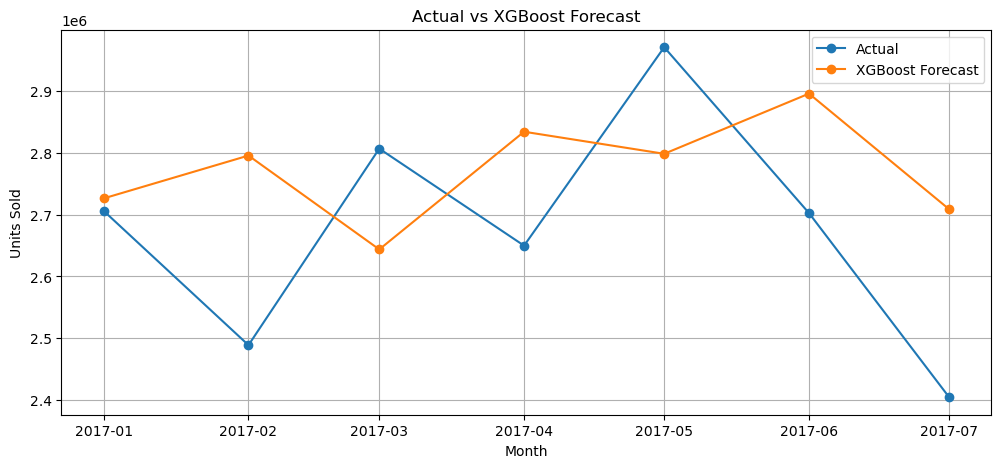

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test.values, marker="o", label="Actual")
plt.plot(xgb_forecast.index, xgb_forecast.values, marker="o", label="XGBoost Forecast")

plt.title("Actual vs XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)

plt.show()

In [185]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)


month              0.181726
lag_12             0.176851
rolling_mean_6     0.136862
lag_3              0.119928
rolling_mean_12    0.115257
rolling_mean_3     0.110365
lag_2              0.094380
lag_1              0.064630
quarter            0.000000
dtype: float32


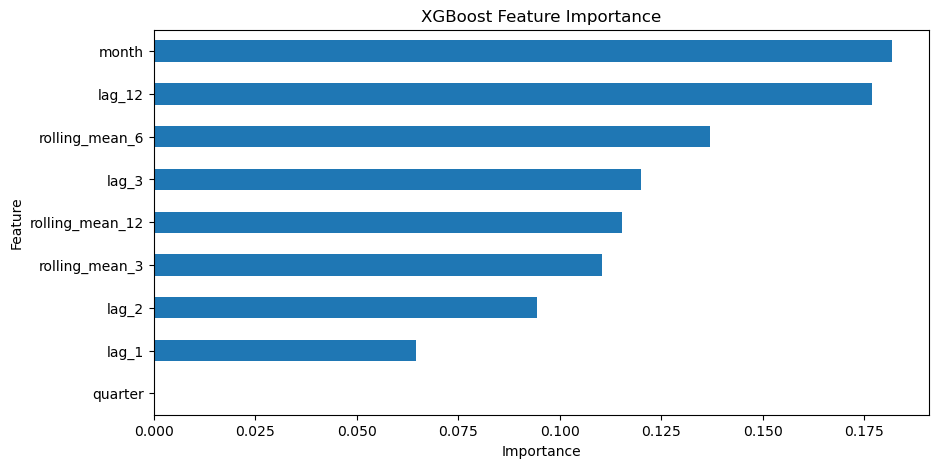

In [186]:
plt.figure(figsize=(10, 5))

importance.sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [187]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

validation_results = []

# Validation periods
validation_periods = [
    ("2015-01-01", "2015-06-01"),
    ("2016-01-01", "2016-06-01"),
    ("2017-01-01", "2017-06-01")
]

for test_start, test_end in validation_periods:

    train_end = (
        pd.to_datetime(test_start) - pd.DateOffset(months=1)
    ).strftime("%Y-%m-%d")

    X_train_wf = X.loc[:"{}".format(train_end)]
    y_train_wf = y.loc[:"{}".format(train_end)]

    X_test_wf = X.loc[test_start:test_end]
    y_test_wf = y.loc[test_start:test_end]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train_wf, y_train_wf)

    forecast = model.predict(X_test_wf)

    mae = mean_absolute_error(y_test_wf, forecast)
    rmse = np.sqrt(mean_squared_error(y_test_wf, forecast))
    mape = np.mean(
        np.abs((y_test_wf - forecast) / y_test_wf)
    ) * 100

    validation_results.append({
        "period": f"{test_start} to {test_end}",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

validation_results = pd.DataFrame(validation_results)

validation_results

,period,MAE,RMSE,MAPE
0,2015-01-01 to 2015-06-01,194803.203125,242978.905817,7.242561
1,2016-01-01 to 2016-06-01,155760.500000,186083.816298,5.566855
2,2017-01-01 to 2017-06-01,173670.125000,192785.231634,6.477438


In [188]:
validation_results[["MAE", "RMSE", "MAPE"]].mean()

MAE     174744.609375
RMSE    207282.651249
MAPE         6.428951
dtype: float64

In [189]:
seasonal_validation_results = []

validation_periods = [
    ("2015-01-01", "2015-06-01"),
    ("2016-01-01", "2016-06-01"),
    ("2017-01-01", "2017-06-01")
]

for test_start, test_end in validation_periods:

    test_index = monthly_sales.loc[
        test_start:test_end
    ].index

    # Same month from previous year
    seasonal_forecast = monthly_sales["units_sold"].shift(12).loc[test_index]

    actual = monthly_sales["units_sold"].loc[test_index]

    mae = mean_absolute_error(actual, seasonal_forecast)
    rmse = np.sqrt(mean_squared_error(actual, seasonal_forecast))
    mape = np.mean(
        np.abs((actual - seasonal_forecast) / actual)
    ) * 100

    seasonal_validation_results.append({
        "period": f"{test_start} to {test_end}",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

seasonal_validation_results = pd.DataFrame(
    seasonal_validation_results
)

seasonal_validation_results

,period,MAE,RMSE,MAPE
0,2015-01-01 to 2015-06-01,143309.000000,189464.590320,5.393966
1,2016-01-01 to 2016-06-01,160307.166667,211587.260146,5.694153
2,2017-01-01 to 2017-06-01,204343.166667,230269.406982,7.581920


In [190]:
seasonal_validation_results[["MAE", "RMSE", "MAPE"]].mean()

MAE     169319.777778
RMSE    210440.419149
MAPE         6.223346
dtype: float64

In [191]:
# Last 12 months of historical data
last_12_months = monthly_sales["units_sold"].iloc[-12:]

# Create next 12 months
future_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

# Seasonal Naive forecast
future_forecast = pd.Series(
    last_12_months.values,
    index=future_dates
)

future_forecast

2017-08-01    2839784
2017-09-01    2895057
2017-10-01    2877183
2017-11-01    3051106
2017-12-01    2477995
2018-01-01    2706289
2018-02-01    2488645
2018-03-01    2807154
2018-04-01    2649917
2018-05-01    2971572
2018-06-01    2702702
2018-07-01    2404223
Freq: MS, dtype: int64

In [192]:
forecast_df = pd.DataFrame({
    "forecast_date": future_forecast.index,
    "forecast_units_sold": future_forecast.values
})

forecast_df

,forecast_date,forecast_units_sold
0,2017-08-01,2839784
1,2017-09-01,2895057
2,2017-10-01,2877183
3,2017-11-01,3051106
4,2017-12-01,2477995
5,2018-01-01,2706289
6,2018-02-01,2488645
7,2018-03-01,2807154
8,2018-04-01,2649917
9,2018-05-01,2971572


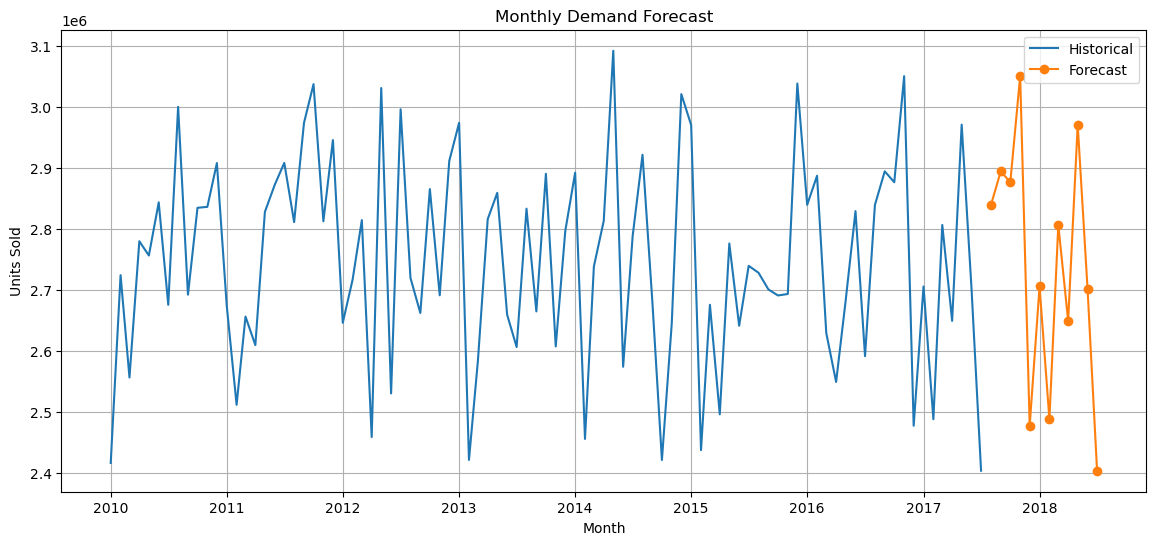

In [193]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales["units_sold"],
    label="Historical"
)

plt.plot(
    forecast_df["forecast_date"],
    forecast_df["forecast_units_sold"],
    marker="o",
    label="Forecast"
)

plt.title("Monthly Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)

plt.show()

In [194]:
forecast_df

,forecast_date,forecast_units_sold
0,2017-08-01,2839784
1,2017-09-01,2895057
2,2017-10-01,2877183
3,2017-11-01,3051106
4,2017-12-01,2477995
5,2018-01-01,2706289
6,2018-02-01,2488645
7,2018-03-01,2807154
8,2018-04-01,2649917
9,2018-05-01,2971572


In [195]:
forecast_df["year"] = forecast_df["forecast_date"].dt.year
forecast_df["month"] = forecast_df["forecast_date"].dt.month
forecast_df["month_name"] = forecast_df["forecast_date"].dt.month_name()

In [196]:
forecast_df

,forecast_date,forecast_units_sold,year,month,month_name
0,2017-08-01,2839784,2017,8,August
1,2017-09-01,2895057,2017,9,September
2,2017-10-01,2877183,2017,10,October
3,2017-11-01,3051106,2017,11,November
4,2017-12-01,2477995,2017,12,December
5,2018-01-01,2706289,2018,1,January
6,2018-02-01,2488645,2018,2,February
7,2018-03-01,2807154,2018,3,March
8,2018-04-01,2649917,2018,4,April
9,2018-05-01,2971572,2018,5,May


In [197]:
historical_df = monthly_sales[["units_sold"]].copy()

historical_df = historical_df.reset_index()

historical_df.rename(
    columns={
        "Order Date": "date",
        "units_sold": "units_sold"
    },
    inplace=True
)

historical_df["data_type"] = "Actual"

In [198]:
forecast_output = forecast_df[
    ["forecast_date", "forecast_units_sold"]
].copy()

forecast_output.rename(
    columns={
        "forecast_date": "date",
        "forecast_units_sold": "units_sold"
    },
    inplace=True
)

forecast_output["data_type"] = "Forecast"

In [199]:
combined_forecast = pd.concat(
    [historical_df, forecast_output],
    ignore_index=True
)

combined_forecast.head()

,date,units_sold,data_type
0,2010-01-01,2416955,Actual
1,2010-02-01,2724860,Actual
2,2010-03-01,2557032,Actual
3,2010-04-01,2780481,Actual
4,2010-05-01,2757045,Actual


In [200]:
combined_forecast.tail(15)

,date,units_sold,data_type
88,2017-05-01,2971572,Actual
89,2017-06-01,2702702,Actual
90,2017-07-01,2404223,Actual
91,2017-08-01,2839784,Forecast
92,2017-09-01,2895057,Forecast
93,2017-10-01,2877183,Forecast
94,2017-11-01,3051106,Forecast
95,2017-12-01,2477995,Forecast
96,2018-01-01,2706289,Forecast
97,2018-02-01,2488645,Forecast


In [201]:
forecast_df.to_csv(
    "monthly_forecast.csv",
    index=False
)

In [202]:
combined_forecast.to_csv(
    "historical_forecast_combined.csv",
    index=False
)

In [203]:
import os

print(os.path.exists("monthly_forecast.csv"))
print(os.path.exists("historical_forecast_combined.csv"))

True
True


In [204]:
forecast_to_mysql = forecast_df[
    ["forecast_date", "forecast_units_sold"]
].copy()

forecast_to_mysql["model_name"] = "Seasonal Naive"

forecast_to_mysql

,forecast_date,forecast_units_sold,model_name
0,2017-08-01,2839784,Seasonal Naive
1,2017-09-01,2895057,Seasonal Naive
2,2017-10-01,2877183,Seasonal Naive
3,2017-11-01,3051106,Seasonal Naive
4,2017-12-01,2477995,Seasonal Naive
5,2018-01-01,2706289,Seasonal Naive
6,2018-02-01,2488645,Seasonal Naive
7,2018-03-01,2807154,Seasonal Naive
8,2018-04-01,2649917,Seasonal Naive
9,2018-05-01,2971572,Seasonal Naive


In [205]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Root@123",
    database="retail_sales_analytics"
)

cursor = conn.cursor()

query = """
INSERT INTO monthly_forecast
    (forecast_date, forecast_units_sold, model_name)
VALUES (%s, %s, %s)
ON DUPLICATE KEY UPDATE
    forecast_units_sold = VALUES(forecast_units_sold),
    model_name = VALUES(model_name)
"""

rows = [
    (
        row.forecast_date.to_pydatetime().date(),
        int(row.forecast_units_sold),
        "Seasonal Naive"
    )
    for row in forecast_df.itertuples(index=False)
]

cursor.executemany(query, rows)
conn.commit()

print("Forecast rows processed:", cursor.rowcount)

cursor.close()
conn.close()

Forecast rows processed: 12
